### import libraries

"scale_kz" will be deprecated, use "grid_z and grid_kz" instead


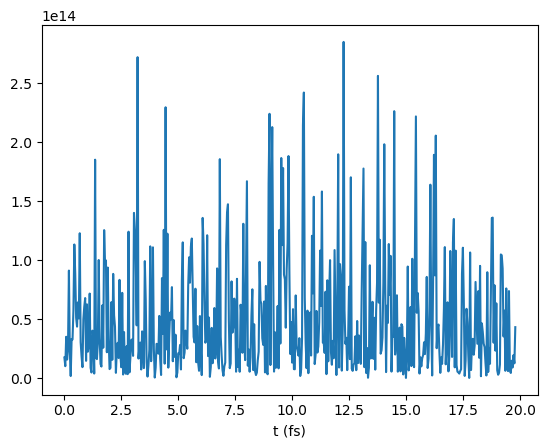

In [4]:
import os
notebook_path = os.path.abspath("__file__")
notebook_directory = os.path.dirname(notebook_path)
mini_ocelot_path = notebook_directory + '/mini_ocelot/'

import sys
sys.path.append(mini_ocelot_path)

from o_globals import *
from math_op import find_nearest_idx, fwhm, std_moment, bin_scale, bin_array, mut_coh_func
from py_func import filename_from_path
from ocelog import *
from new_wave import *
import scipy.constants as sp_const

SASE = RadiationField()  # initialize RadiationField object

# The transverse domain is considered to be space [m], since I hace input
# parameters in time [fs], the correct conversion is needed


kwargs={'xlamds':1e-9*0.154,                     # [m] - central wavelength
        'shape':(16, 16, 500),            # size of field matrix (x,y,z=ct) (number of points)
        'dgrid':(2e-9*1000, 2e-9*1000, 1e-15*20*sp_const.c),                # size of field grid (max value) 
        'power_rms':(1e-9*200, 1e-9*200, 1e-15*10*sp_const.c),   # rms size of radiation distribution
        'power_center':(0,0,None),                      # (x,y,z) [m] - position of the radiation distribution
        'power_angle':(0,0),                            # (x,y) [rad] - angle of further radiation propagation
        'power_waistpos':(0,0),                         # (Z_x,Z_y) [m] downstrean location of the waist of the beam
        'wavelength':None,                              # central frequency of the radiation, if different from xlamds
        'zsep':None,                                    # distance between slices in z as zsep*xlamds
        'freq_chirp':0,                                 # dw/dt=[1/fs**2] - requency chirp of the beam around power_center[2]
        'en_pulse':40e-6,        # total energy or max power of the pulse, use only one
        'power':None,
        'rho':0.01/2
        }

SASE = imitate_sase_dfl(**kwargs);

field_txy = SASE.fld

# Normalization: it has to be compatible with the units used in the rest of
# the code. imitate_sase_dfl uses SI units [m, s, J], need to normalize with
# respect to [nm, fs, eV]

dx = 1e9 * (SASE.Lx() / SASE.Nx())
dy = 1e9 * (SASE.Ly() / SASE.Ny())
dt = 1e15 * (SASE.Lz() / SASE.Nz()) / sp_const.c


plt.figure()
plt.plot(np.linspace(0, SASE.Lz()*1.e15/sp_const.c, 500), np.abs(field_txy[:,1,1])**2)
plt.xlabel('t (fs)')
plt.show()

In [33]:
X.n * (X.sigma1_Ka1_2p3  + X.sigma1_Ka1_other) * X.zmax

0.96700548

In [26]:
np.exp( -X.n * (X.sigma1_Ka1_2p3  + X.sigma1_Ka1_other) * X.zmax)

0.3802199111877119

In [35]:
res_mu_estimate = 3 / (8 * np.pi) * X.n * X.lambdaKalpha1N**2 * X.Gamma_sp_fsm1N / X.Gamma_ij * 0.001

In [36]:
res_mu_estimate * X.zmax

2.6554651885107243

In [31]:
X.Gamma_sp_fsm1N / X.Gamma_ij

0.5680171428571429

In [44]:
N_seed_photons = X.E_seed_uJ * 1e-6 / (X.hwKalpha1N * sp_const.e)

In [45]:
f'{N_seed_photons:.1e}'

'3.1e+10'

In [46]:
f'{X.n * X.zmax * X.seed_width_FWHM_x * X.seed_width_FWHM_y:.1e}'

'6.5e+10'